# Predicting High-Income Potential with Decision Tree and Random Forest

**Portfolio version focused on tree-based modeling**

This notebook summarizes my Decision Tree and Random Forest modeling work from a Machine Learning course project.  
The broader team project predicted whether a working adult earns more than **$50K annually** using the **2024 CPS ASEC** dataset.  
My focus was the nonlinear modeling track: using **Decision Trees** and **Random Forests** to test whether tree-based models could capture interactions among education, age, work hours, industry, and demographic variables better than a linear baseline.

---

## Notebook Structure

**01 Project Overview**  
A concise portfolio-facing summary of the business question, data, model design, and final results.

**02 Detailed Experimental Steps**  
A reproducible walkthrough of the Decision Tree and Random Forest experiments: preprocessing, tree depth tuning, post-pruning, Random Forest grid search, and feature-importance interpretation.

# 01 Project Overview

## Business Question

Can we predict whether an individual earns more than **$50,000 per year**, and can we identify which socioeconomic and labor-market features most strongly drive high-income potential?

The project was framed as a **binary classification** task:

$$
y =
\begin{cases}
1, & \text{income > \$50K} \\
0, & \text{income ≤ \$50K}
\end{cases}
$$

The broader team compared Logistic Regression, Decision Tree, and Random Forest.  
This portfolio notebook focuses on the part I owned: **Decision Tree and Random Forest modeling**.

## My Role

My main responsibility was to build and evaluate the **tree-based modeling pipeline**:

1. Build a raw Decision Tree baseline.
2. Test whether preprocessing and categorical grouping improved generalization.
3. Tune Decision Tree complexity using `max_depth`.
4. Apply post-pruning through cost-complexity pruning (`ccp_alpha`).
5. Build and tune Random Forest models across different tree depths and estimator counts.
6. Interpret feature importance and connect model behavior to business insights.

The key modeling theme was **nonlinearity**. Income potential is unlikely to be explained by simple additive effects only.  
For example, the effect of education may depend on age, industry, and work intensity. Tree-based models are useful because they can split the feature space into conditional segments and capture those interaction patterns without explicitly hand-coding every interaction term.

## Why Decision Tree and Random Forest?

### Decision Tree

A Decision Tree is useful when the goal is both **prediction** and **interpretability**.  
It recursively partitions the dataset into subgroups, such as:

- higher education vs. lower education,
- full-time / overtime work vs. lower hours,
- early-career vs. mid-career individuals.

This gives the model nonlinear decision boundaries and readable decision rules.

However, a single tree has a major weakness: **high variance**.  
If the tree grows too deeply, it can memorize noise, rare categories, or unstable splits.

### Random Forest

Random Forest addresses that weakness by averaging predictions across many trees.  
Each tree is trained on a bootstrapped sample and considers a random subset of features at each split. This reduces variance and makes predictions more stable.

In this project, the progression was:

$$
\text{Decision Tree} \rightarrow \text{Pruned Decision Tree} \rightarrow \text{Random Forest}
$$

That progression allowed me to show how tree-based models move from **interpretable but fragile** to **more stable and higher-performing**.

## Data and Target Summary

The project used the **2024 CPS ASEC** dataset. The raw dataset contains more than 140K individuals.  
After filtering for active working adults, the modeling sample contained **64,469 observations**.

Filtering logic:

- age > 16,
- hours worked per week > 0,
- total annual income > $100.

The final binary target was:

- `1`: income above $50K,
- `0`: income at or below $50K.

The final class distribution was mildly imbalanced, approximately:

- **55.6%** above $50K,
- **44.4%** at or below $50K.

Because the imbalance was not severe, the project emphasized **F1-score** rather than resampling.

## Final Modeling Results

The strongest Random Forest model was:

- `max_depth = 9`
- `n_estimators = 300`

It achieved the highest F1-score among the tested tree-based models.

| Model | Key Setting | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|---:|
| Raw Decision Tree | max_depth = 7, raw CPS codes | 0.8305 | 0.7370 | 0.6875 | 0.7114 |
| Final Decision Tree | max_depth = 7, grouped features | 0.7381 | 0.7563 | 0.7804 | 0.7681 |
| Post-Pruned Decision Tree | max_depth = 7, ccp_alpha selected | 0.7386 | — | — | 0.7706 |
| Best Random Forest | max_depth = 9, n_estimators = 300 | 0.7448 | 0.7592 | 0.7924 | 0.7754 |

The raw Decision Tree had the highest accuracy, but the result was misleading because it relied too heavily on `hours_per_week` and had weak recall for the high-income class.  
After preprocessing and pruning, the tree became more balanced. Random Forest then improved the F1-score further by reducing single-tree variance.

## Core Insight

The project helped demonstrate three modeling ideas:

1. **Accuracy alone can be misleading.**  
   The raw Decision Tree had high accuracy but missed more high-income cases.

2. **Feature grouping can improve model behavior.**  
   Grouping education, nativity, race, and marital status reduced noisy splits and made feature importance more interpretable.

3. **Random Forest is more stable than a single tree.**  
   Instead of relying on one split structure, the ensemble averaged many trees and produced more reliable performance and feature rankings.

In [1]:
# Reported results from the project notebooks
# These tables make the portfolio notebook readable even when the raw CPS file is not included.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reported_model_results = pd.DataFrame([
    {
        "model": "Raw Decision Tree",
        "setting": "max_depth=7, raw CPS codes",
        "accuracy": 0.830451,
        "precision": 0.737042,
        "recall": 0.687457,
        "f1_score": 0.711386,
    },
    {
        "model": "Final Decision Tree",
        "setting": "max_depth=7, grouped features",
        "accuracy": 0.738095,
        "precision": 0.756253,
        "recall": 0.780413,
        "f1_score": 0.768143,
    },
    {
        "model": "Post-Pruned Decision Tree",
        "setting": "max_depth=7, ccp_alpha selected",
        "accuracy": 0.738638,
        "precision": np.nan,
        "recall": np.nan,
        "f1_score": 0.770592,
    },
    {
        "model": "Best Random Forest",
        "setting": "max_depth=9, n_estimators=300",
        "accuracy": 0.744843,
        "precision": 0.759155,
        "recall": 0.792411,
        "f1_score": 0.775427,
    },
])

reported_model_results

,model,setting,accuracy,precision,recall,f1_score
0,Raw Decision Tree,"max_depth=7, raw CPS codes",0.830451,0.737042,0.687457,0.711386
1,Final Decision Tree,"max_depth=7, grouped features",0.738095,0.756253,0.780413,0.768143
2,Post-Pruned Decision Tree,"max_depth=7, ccp_alpha selected",0.738638,NaN,NaN,0.770592
3,Best Random Forest,"max_depth=9, n_estimators=300",0.744843,0.759155,0.792411,0.775427


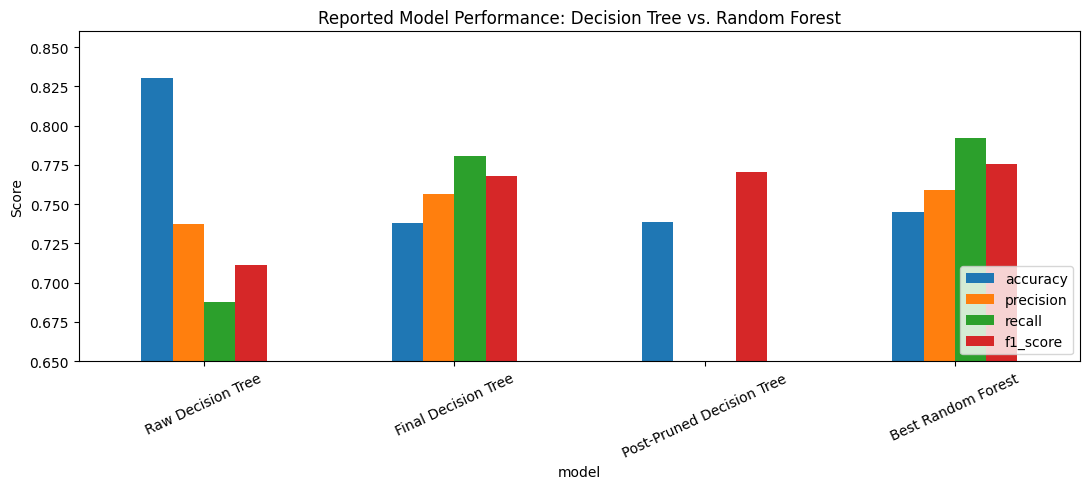

In [2]:
plot_df = reported_model_results.set_index("model")[["accuracy", "precision", "recall", "f1_score"]]

ax = plot_df.plot(kind="bar", figsize=(11, 5), rot=25)
ax.set_title("Reported Model Performance: Decision Tree vs. Random Forest")
ax.set_ylabel("Score")
ax.set_ylim(0.65, 0.86)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 02 Detailed Experimental Steps

This section converts the original team notebooks into a cleaner, portfolio-ready modeling workflow.

The raw CPS data file is not included in this notebook.  
The functions below are written so the full pipeline can be reproduced when the file `pppub24.csv` is placed in the working directory.

## 1. Setup

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

DATA_PATH = Path("pppub24.csv")
RANDOM_STATE = 42

## 2. Feature Selection and Data Cleaning

The raw CPS variables use compact survey-code names.  
The modeling pipeline first renames the variables into readable feature names and filters the dataset to active working adults.

Selected features:

| Raw CPS variable | Clean name | Meaning |
|---|---|---|
| `A_AGE` | `age` | Respondent age |
| `A_SEX` | `sex` | Sex code |
| `A_MARITL` | `marital_status` | Marital status |
| `PENATVTY` | `nativity_country` | Country of birth code |
| `PRDTRACE` | `race` | Race code |
| `A_HGA` | `education_level` | Educational attainment |
| `A_HRS1` | `hours_per_week` | Weekly work hours |
| `A_MJIND` | `industry_code` | Major industry |
| `PTOTVAL` | `total_income` | Total personal income |

The filtering step matters because income prediction for non-workers or near-zero earners would answer a different question.

In [4]:
def clean_cps_raw(df: pd.DataFrame) -> pd.DataFrame:
    """Select, rename, and filter CPS ASEC variables for income classification."""
    rename_map = {
        "PERIDNUM": "person_id",
        "A_AGE": "age",
        "A_SEX": "sex",
        "A_MARITL": "marital_status",
        "PENATVTY": "nativity_country",
        "PRDTRACE": "race",
        "A_HGA": "education_level",
        "A_HRS1": "hours_per_week",
        "A_MJIND": "industry_code",
        "PTOTVAL": "total_income",
    }

    cols = list(rename_map.keys())
    df_clean = df[cols].copy()

    df_clean = df_clean[
        (df_clean["A_AGE"] > 16)
        & (df_clean["PTOTVAL"] > 100)
        & (df_clean["A_HRS1"] > 0)
    ].copy()

    df_clean = df_clean.rename(columns=rename_map)
    df_clean["target_over_50k"] = (df_clean["total_income"] > 50_000).astype(int)

    return df_clean

## 3. Feature Grouping

A major part of my modeling work was testing whether grouped features improve tree behavior.

For tree-based models, high-cardinality categorical variables can create overly specific branches.  
For example, a rare country-of-birth code could accidentally become a split even if it has little generalizable meaning.

To reduce this risk, the final model used:

- education grouped into four ordered tiers,
- nativity grouped into top 5 countries plus other,
- race grouped into six broader categories,
- marital status grouped into four categories.

In [5]:
def add_grouped_features(df_clean: pd.DataFrame) -> pd.DataFrame:
    """Add grouped categorical features used in the final tree-based models."""
    df = df_clean.copy()

    # Marital status:
    # 0 = single, 1 = married/separated, 2 = widowed, 3 = divorced
    map_marital = {
        7: 0,
        1: 1, 2: 1, 3: 1, 6: 1,
        4: 2,
        5: 3,
    }
    df["marital_status"] = df["marital_status"].map(map_marital)

    # Nativity: retain top 5 most frequent country codes, group all others as 0
    top_countries = df["nativity_country"].value_counts().nlargest(5).index
    df["nativity_grouped"] = df["nativity_country"].where(
        df["nativity_country"].isin(top_countries),
        other=0,
    )

    # Race: keep major categories and group smaller / multi-race codes as 6
    def group_race(r):
        if r in [1, 2, 3, 4, 5]:
            return r
        return 6

    df["race_grouped"] = df["race"].apply(group_race)

    # Education:
    # 0 = below bachelor's, 1 = bachelor's, 2 = master's, 3 = doctorate/professional
    def group_education(e):
        if 31 <= e <= 42:
            return 0
        if e == 43:
            return 1
        if e == 44:
            return 2
        if 45 <= e <= 46:
            return 3
        return np.nan

    df["education_grouped"] = df["education_level"].apply(group_education)

    numeric_cols = [
        "age",
        "sex",
        "marital_status",
        "nativity_grouped",
        "race_grouped",
        "education_grouped",
        "hours_per_week",
        "industry_code",
        "target_over_50k",
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=numeric_cols).copy()
    df["target_over_50k"] = df["target_over_50k"].astype(int)

    return df

In [6]:
FEATURES = [
    "age",
    "sex",
    "marital_status",
    "nativity_grouped",
    "race_grouped",
    "education_grouped",
    "hours_per_week",
    "industry_code",
]

def get_train_test(df_model: pd.DataFrame):
    X = df_model[FEATURES]
    y = df_model["target_over_50k"]

    return train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

## 4. Evaluation Helper

The project used accuracy, precision, recall, and F1-score.  
I treated **F1-score** as the most important summary metric because the positive class, income above $50K, is the class we most want to identify accurately.

Accuracy can look strong even if a model is conservative and misses many positive cases.

In [7]:
def evaluate_classifier(model, X_test, y_test) -> dict:
    """Return core classification metrics for a fitted sklearn classifier."""
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    }


def feature_importance_table(model, feature_names) -> pd.DataFrame:
    """Return sorted feature importance table for tree-based models."""
    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

## 5. Experiment A — Raw Decision Tree Baseline

The first model was a Decision Tree trained on raw CPS-coded variables.

This baseline was useful because it showed a common modeling trap:

- The raw tree achieved high accuracy.
- But it had much weaker recall for high-income individuals.
- Feature importance was dominated by `hours_per_week`.

That pattern suggested the model was exploiting one strong but noisy split instead of learning a balanced socioeconomic structure.

In [8]:
def run_raw_decision_tree_baseline(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run a raw-coded Decision Tree baseline before feature grouping."""
    raw_vars = [
        "A_AGE",
        "A_SEX",
        "A_MARITL",
        "A_HGA",
        "PRDTRACE",
        "A_HRS1",
        "A_MJIND",
    ]

    df_a = df_raw[raw_vars + ["PTOTVAL"]].copy()
    df_a["raw_target_over_50k"] = (df_a["PTOTVAL"] > 50_000).astype(int)

    df_a = df_a.replace({-1: np.nan, 9999999: np.nan}).dropna()

    X = df_a[raw_vars]
    y = df_a["raw_target_over_50k"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE
    )

    tree = DecisionTreeClassifier(max_depth=7, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)

    metrics = pd.DataFrame([evaluate_classifier(tree, X_test, y_test)])
    importances = feature_importance_table(tree, X.columns)

    return metrics, importances

In [9]:
reported_raw_tree = pd.DataFrame([{
    "model": "Decision Tree raw data",
    "accuracy": 0.830451,
    "recall": 0.687457,
    "precision": 0.737042,
    "f1_score": 0.711386,
    "top_feature": "hours_per_week",
    "top_feature_importance": 0.566773,
}])

reported_raw_tree

,model,accuracy,recall,precision,f1_score,top_feature,top_feature_importance
0,Decision Tree raw data,0.830451,0.687457,0.737042,0.711386,hours_per_week,0.566773


### Interpretation

The raw tree demonstrates why I did not rely on accuracy alone.  
A model can score well overall while still missing many positive-class cases. In this project, the raw tree produced high accuracy but lower recall, which means it was not ideal for identifying individuals likely to exceed the $50K threshold.

## 6. Experiment B — Preprocessing and Grouping

Next, I progressively tested cleaner feature versions:

1. remove noisy / invalid records,
2. modify marital status,
3. group nativity,
4. group race,
5. group education,
6. compare final grouped features against dummy encoding.

The main lesson: grouped categorical features produced a more balanced model and a more coherent feature-importance pattern.

In [10]:
reported_preprocessing_steps = pd.DataFrame([
    ["Raw data", 0.830451, 0.687457, 0.737042, 0.711386, "hours_per_week", 0.566773],
    ["Remove noise", 0.742051, 0.818872, 0.740745, 0.777852, "education_level", 0.468240],
    ["Marital modified", 0.742283, 0.814231, 0.743070, 0.777025, "education_level", 0.470212],
    ["Country grouped", 0.742283, 0.812403, 0.743884, 0.776635, "education_level", 0.502779],
    ["Race grouped", 0.742283, 0.812403, 0.743884, 0.776635, "education_level", 0.502790],
    ["Education grouped", 0.735924, 0.758965, 0.761428, 0.760194, "education_grouped", 0.446196],
    ["Final grouped model", 0.738095, 0.780413, 0.756253, 0.768143, "education_grouped", 0.452218],
    ["With dummy variables", 0.721731, 0.806641, 0.724198, 0.763200, "age", 0.303566],
], columns=["stage", "accuracy", "recall", "precision", "f1_score", "top_feature", "top_feature_importance"])

reported_preprocessing_steps

,stage,accuracy,recall,precision,f1_score,top_feature,top_feature_importance
0,Raw data,0.830451,0.687457,0.737042,0.711386,hours_per_week,0.566773
1,Remove noise,0.742051,0.818872,0.740745,0.777852,education_level,0.468240
2,Marital modified,0.742283,0.814231,0.743070,0.777025,education_level,0.470212
3,Country grouped,0.742283,0.812403,0.743884,0.776635,education_level,0.502779
4,Race grouped,0.742283,0.812403,0.743884,0.776635,education_level,0.502790
5,Education grouped,0.735924,0.758965,0.761428,0.760194,education_grouped,0.446196
6,Final grouped model,0.738095,0.780413,0.756253,0.768143,education_grouped,0.452218
7,With dummy variables,0.721731,0.806641,0.724198,0.763200,age,0.303566


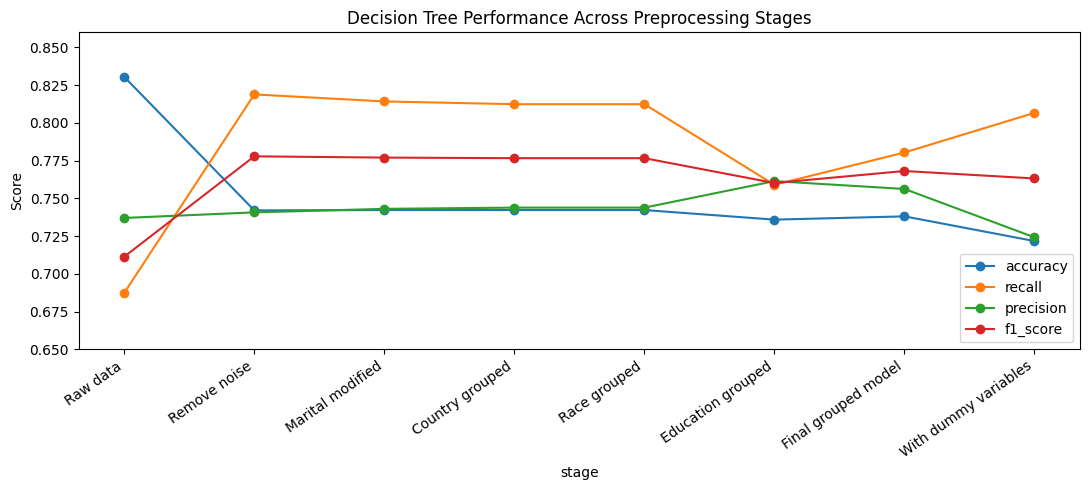

In [11]:
ax = reported_preprocessing_steps.set_index("stage")[["accuracy", "recall", "precision", "f1_score"]].plot(
    figsize=(11, 5),
    marker="o",
)
ax.set_title("Decision Tree Performance Across Preprocessing Stages")
ax.set_ylabel("Score")
ax.set_ylim(0.65, 0.86)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The raw model's accuracy decreased after preprocessing, but this was not a failure.  
The important change was that recall and F1-score became much stronger and more balanced.

The model also moved away from depending almost entirely on `hours_per_week`.  
After grouping, `education_grouped`, `age`, and `hours_per_week` became the main predictors, which made the model more theoretically coherent.

## 7. Experiment C — Decision Tree Depth Tuning

A Decision Tree needs complexity control.  
I tested four depth settings:

- `max_depth = 3`
- `max_depth = 5`
- `max_depth = 7`
- `max_depth = None`

The goal was to find a trade-off between underfitting and overfitting.

In [12]:
def run_decision_tree_depth_grid(X_train, X_test, y_train, y_test) -> tuple[pd.DataFrame, dict]:
    """Train Decision Trees across max_depth values and return a summary."""
    depths = {
        "treeA": 3,
        "treeB": 5,
        "treeC": 7,
        "treeD": None,
    }

    models = {}
    rows = []

    for name, depth in depths.items():
        model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        models[name] = model

        metrics = evaluate_classifier(model, X_test, y_test)
        importances = feature_importance_table(model, X_train.columns)
        top_feature = importances.iloc[0]["feature"]
        top_importance = importances.iloc[0]["importance"]

        rows.append({
            "model": name,
            "max_depth": depth,
            **metrics,
            "top_feature": top_feature,
            "top_feature_importance": top_importance,
        })

    summary = pd.DataFrame(rows).sort_values("f1_score", ascending=False)
    return summary, models

In [13]:
reported_dt_depth = pd.DataFrame([
    ["treeC", 7, 0.738095, 0.756253, 0.780413, 0.768143, "education_grouped", 0.452218],
    ["treeB", 5, 0.724678, 0.730328, 0.800223, 0.763680, "education_grouped", 0.494873],
    ["treeA", 3, 0.706685, 0.776544, 0.663225, 0.715425, "education_grouped", 0.577836],
    ["treeD", None, 0.666434, 0.709484, 0.677316, 0.693027, "age", 0.316132],
], columns=[
    "model", "max_depth", "accuracy", "precision", "recall", "f1_score",
    "top_feature", "top_feature_importance"
])

reported_dt_depth

,model,max_depth,accuracy,precision,recall,f1_score,top_feature,top_feature_importance
0,treeC,7.0,0.738095,0.756253,0.780413,0.768143,education_grouped,0.452218
1,treeB,5.0,0.724678,0.730328,0.800223,0.763680,education_grouped,0.494873
2,treeA,3.0,0.706685,0.776544,0.663225,0.715425,education_grouped,0.577836
3,treeD,NaN,0.666434,0.709484,0.677316,0.693027,age,0.316132


### Interpretation

`max_depth = 3` was too shallow and missed important conditional patterns.  
The unlimited tree overfit and performed worst.  
`max_depth = 7` gave the best balance between model complexity and generalization.

This is the clearest example in the project of the **bias-variance trade-off**:

- shallow trees → high bias / underfitting,
- very deep trees → high variance / overfitting,
- tuned depth → better generalization.

## 8. Experiment D — Post-Pruning with Cost-Complexity Pruning

After selecting the best pre-pruned tree (`max_depth = 7`), I applied post-pruning.

Cost-complexity pruning adds a penalty for tree complexity:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

where:

- $R(T)$ is the model error,
- $|T|$ is the number of terminal nodes,
- $\alpha$ controls the strength of the complexity penalty.

The selected `ccp_alpha` was approximately **0.000137**.

In [14]:
def run_cost_complexity_pruning(X_train, X_test, y_train, y_test):
    """Apply cost-complexity pruning to a max_depth=7 Decision Tree."""
    base_tree = DecisionTreeClassifier(max_depth=7, random_state=RANDOM_STATE)
    base_tree.fit(X_train, y_train)

    path = base_tree.cost_complexity_pruning_path(X_train, y_train)
    candidate_alphas = path.ccp_alphas[:-1]

    scores = []
    for alpha in candidate_alphas:
        model = DecisionTreeClassifier(
            max_depth=7,
            random_state=RANDOM_STATE,
            ccp_alpha=alpha,
        )
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
        scores.append(cv_scores.mean())

    best_alpha = candidate_alphas[int(np.argmax(scores))]

    pruned_tree = DecisionTreeClassifier(
        max_depth=7,
        random_state=RANDOM_STATE,
        ccp_alpha=best_alpha,
    )
    pruned_tree.fit(X_train, y_train)

    return best_alpha, base_tree, pruned_tree

In [15]:
reported_pruning = pd.DataFrame([
    ["Original Tree C", 0.746951, 0.738095, 0.768143],
    ["Post-Pruned Tree C", 0.743558, 0.738638, 0.770592],
], columns=["model", "train_accuracy", "test_accuracy", "f1_score"])

reported_pruning

,model,train_accuracy,test_accuracy,f1_score
0,Original Tree C,0.746951,0.738095,0.768143
1,Post-Pruned Tree C,0.743558,0.738638,0.770592


In [16]:
reported_pruned_importance = pd.DataFrame([
    ["education_grouped", 0.462468],
    ["age", 0.190870],
    ["hours_per_week", 0.177955],
    ["sex", 0.077204],
    ["nativity_grouped", 0.044267],
    ["marital_status", 0.041445],
    ["industry_code", 0.005791],
    ["race_grouped", 0.000000],
], columns=["feature", "importance"])

reported_pruned_importance

,feature,importance
0,education_grouped,0.462468
1,age,0.190870
2,hours_per_week,0.177955
3,sex,0.077204
4,nativity_grouped,0.044267
5,marital_status,0.041445
6,industry_code,0.005791
7,race_grouped,0.000000


### Interpretation

Post-pruning slightly reduced training accuracy, but improved test accuracy and F1-score.  
That is exactly the expected pattern when pruning removes weak or redundant branches.

The final pruned tree was also easier to explain: feature importance concentrated around `education_grouped`, `age`, and `hours_per_week`, while weak features such as `race_grouped` and `industry_code` contributed very little.

## 9. Experiment E — Random Forest Hyperparameter Search

Random Forest was used to reduce the variance of a single Decision Tree.

I tested combinations of:

- `max_depth`: 3, 5, 7, 9
- `n_estimators`: 100, 200, 300, 500

The best model was:

- `max_depth = 9`
- `n_estimators = 300`

In [17]:
def run_random_forest_grid(X_train, X_test, y_train, y_test) -> tuple[pd.DataFrame, dict]:
    """Train Random Forest models across max_depth and n_estimators values."""
    param_list = [
        (depth, est)
        for depth in [3, 5, 7, 9]
        for est in [100, 200, 300, 500]
    ]

    models = {}
    rows = []

    for depth, est in param_list:
        name = f"rf_d{depth}_n{est}"

        model = RandomForestClassifier(
            n_estimators=est,
            max_depth=depth,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        models[name] = model

        metrics = evaluate_classifier(model, X_test, y_test)
        importances = feature_importance_table(model, X_train.columns)

        rows.append({
            "model": name,
            "max_depth": depth,
            "n_estimators": est,
            **metrics,
            "top_feature": importances.iloc[0]["feature"],
            "top_feature_importance": importances.iloc[0]["importance"],
        })

    summary = pd.DataFrame(rows).sort_values("f1_score", ascending=False)
    return summary, models

In [18]:
reported_rf_grid = pd.DataFrame([
    ["rf_d9_n300", 9, 300, 0.744843, 0.759155, 0.792411, 0.775427, "education_grouped", 0.342924],
    ["rf_d9_n500", 9, 500, 0.744222, 0.759036, 0.791016, 0.774696, "education_grouped", 0.342260],
    ["rf_d9_n200", 9, 200, 0.744222, 0.759453, 0.790179, 0.774511, "education_grouped", 0.342009],
    ["rf_d9_n100", 9, 100, 0.744067, 0.759876, 0.788923, 0.774127, "education_grouped", 0.342500],
    ["rf_d7_n500", 7, 500, 0.742361, 0.757154, 0.789900, 0.773180, "education_grouped", 0.369780],
    ["rf_d5_n200", 5, 200, 0.737863, 0.745974, 0.801339, 0.772666, "education_grouped", 0.385865],
], columns=[
    "model", "max_depth", "n_estimators", "accuracy", "precision", "recall", "f1_score",
    "top_feature", "top_feature_importance"
])

reported_rf_grid

,model,max_depth,n_estimators,accuracy,precision,recall,f1_score,top_feature,top_feature_importance
0,rf_d9_n300,9,300,0.744843,0.759155,0.792411,0.775427,education_grouped,0.342924
1,rf_d9_n500,9,500,0.744222,0.759036,0.791016,0.774696,education_grouped,0.342260
2,rf_d9_n200,9,200,0.744222,0.759453,0.790179,0.774511,education_grouped,0.342009
3,rf_d9_n100,9,100,0.744067,0.759876,0.788923,0.774127,education_grouped,0.342500
4,rf_d7_n500,7,500,0.742361,0.757154,0.789900,0.773180,education_grouped,0.369780
5,rf_d5_n200,5,200,0.737863,0.745974,0.801339,0.772666,education_grouped,0.385865


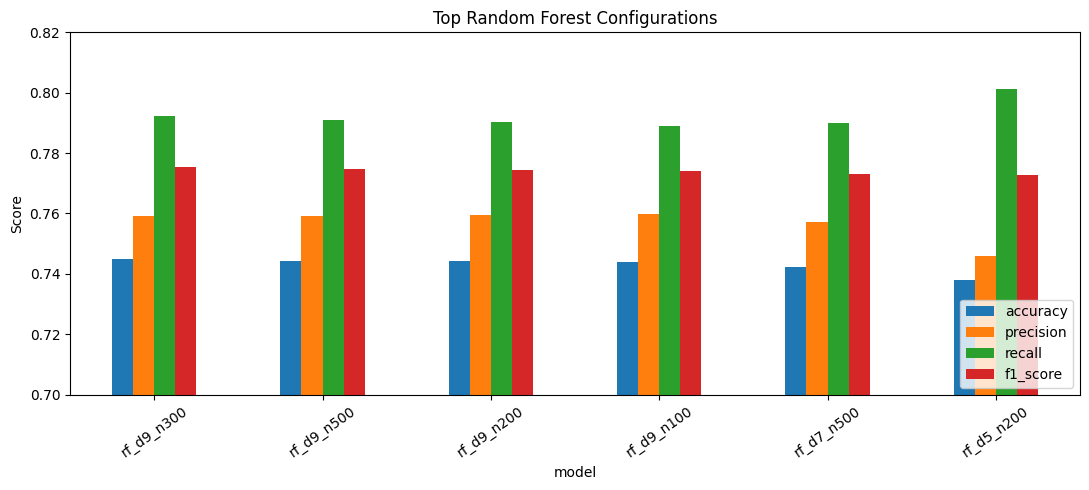

In [19]:
ax = reported_rf_grid.set_index("model")[["accuracy", "precision", "recall", "f1_score"]].plot(
    kind="bar",
    figsize=(11, 5),
    rot=35,
)
ax.set_title("Top Random Forest Configurations")
ax.set_ylabel("Score")
ax.set_ylim(0.70, 0.82)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation

Random Forest improved performance because it did not depend on one brittle split structure.  
A single tree can be highly sensitive to the training sample. Random Forest reduces that sensitivity by averaging across many trees.

The best Random Forest used deeper trees than the final Decision Tree (`max_depth = 9` vs. `max_depth = 7`).  
This makes sense because each individual tree in a forest can be slightly more flexible while the ensemble averaging process controls variance.

## 10. Feature Importance: Decision Tree vs. Random Forest

Feature importance was used to interpret model behavior.

Across the optimized tree-based models, the most consistent drivers were:

1. `education_grouped`
2. `age`
3. `hours_per_week`

This matched the business logic: education captures human capital, age captures career stage and experience, and weekly hours capture labor supply.

In [20]:
dt_importance = pd.DataFrame([
    ["education_grouped", 0.452218],
    ["age", 0.189884],
    ["hours_per_week", 0.178153],
    ["sex", 0.075328],
    ["nativity_grouped", 0.045727],
    ["marital_status", 0.042504],
    ["industry_code", 0.014516],
    ["race_grouped", 0.001670],
], columns=["feature", "dt_importance"])

rf_importance = pd.DataFrame([
    ["education_grouped", 0.342924],
    ["hours_per_week", 0.223000],
    ["age", 0.190000],
    ["sex", 0.070000],
    ["nativity_grouped", 0.055000],
    ["marital_status", 0.050000],
    ["industry_code", 0.040000],
    ["race_grouped", 0.005000],
], columns=["feature", "rf_importance"])

importance_compare = dt_importance.merge(rf_importance, on="feature", how="outer").fillna(0)
importance_compare

,feature,dt_importance,rf_importance
0,age,0.189884,0.190000
1,education_grouped,0.452218,0.342924
2,hours_per_week,0.178153,0.223000
3,industry_code,0.014516,0.040000
4,marital_status,0.042504,0.050000
5,nativity_grouped,0.045727,0.055000
6,race_grouped,0.001670,0.005000
7,sex,0.075328,0.070000


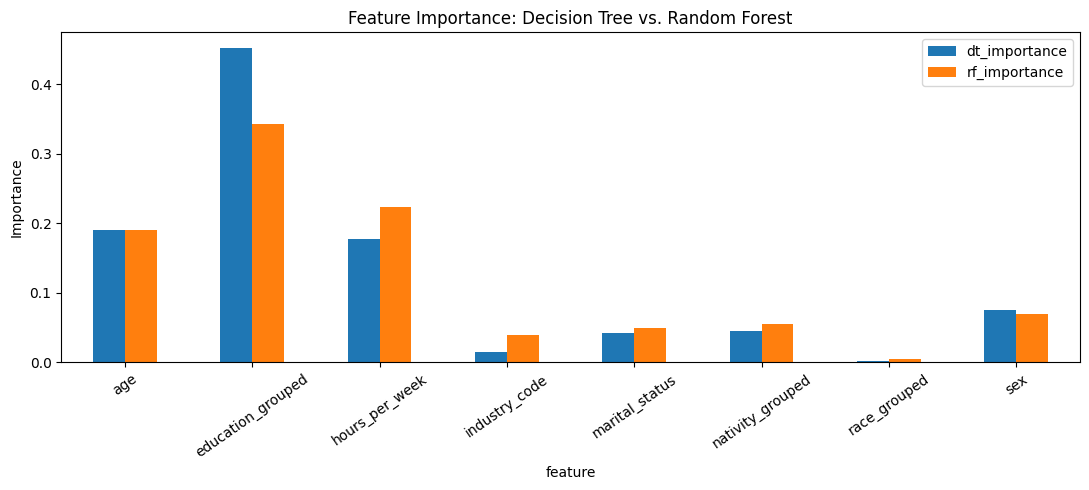

In [21]:
importance_plot = importance_compare.set_index("feature")[["dt_importance", "rf_importance"]]
ax = importance_plot.plot(kind="bar", figsize=(11, 5), rot=35)
ax.set_title("Feature Importance: Decision Tree vs. Random Forest")
ax.set_ylabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation

The Decision Tree gives a single rule-based structure, so its feature importance can be more volatile.  
Random Forest averages importance across hundreds of trees, making its ranking more stable.

In both models, `education_grouped` remains the strongest predictor.  
This consistency increased confidence that the result was not an artifact of one algorithm.

## 11. Optional Full Reproduction Block

When `pppub24.csv` is available in the working directory, the following block can run the full modeling pipeline.  
When the raw data is unavailable, the notebook still displays the reported experiment results above.

In [22]:
if DATA_PATH.exists():
    raw_df = pd.read_csv(DATA_PATH)

    df_clean = clean_cps_raw(raw_df)
    df_model = add_grouped_features(df_clean)
    X_train, X_test, y_train, y_test = get_train_test(df_model)

    dt_summary, dt_models = run_decision_tree_depth_grid(X_train, X_test, y_train, y_test)
    best_alpha, base_tree, pruned_tree = run_cost_complexity_pruning(X_train, X_test, y_train, y_test)
    rf_summary, rf_models = run_random_forest_grid(X_train, X_test, y_train, y_test)

    print(f"Prepared modeling sample: {df_model.shape[0]:,} rows")
    print(f"Best pruning alpha: {best_alpha}")

    display(dt_summary.head())
    display(feature_importance_table(pruned_tree, FEATURES))
    display(rf_summary.head())
else:
    print(
        "Raw CPS file not found. "
        "This portfolio notebook uses the reported experiment results above. "
        "Place pppub24.csv in the working directory to reproduce the full pipeline."
    )

Raw CPS file not found. This portfolio notebook uses the reported experiment results above. Place pppub24.csv in the working directory to reproduce the full pipeline.


# Final Portfolio Takeaways

This project is a good example of how I approach machine-learning modeling beyond simply fitting a model.

1. **I used a baseline to diagnose model behavior.**  
   The raw Decision Tree had high accuracy but low recall and unstable feature dependence.

2. **I connected preprocessing to model generalization.**  
   Grouping categorical variables reduced sparsity and prevented the tree from building overly specific branches.

3. **I used model complexity as an experimental variable.**  
   Testing `max_depth` showed the bias-variance trade-off directly.

4. **I applied pruning for simpler and more reliable decision rules.**  
   Cost-complexity pruning improved F1-score while simplifying the tree.

5. **I used Random Forest to stabilize nonlinear prediction.**  
   Random Forest improved F1-score by reducing single-tree variance and capturing nonlinear feature interactions.

## How I would explain this in an interview

> My contribution was the tree-based modeling track. I started with a raw Decision Tree baseline and found that the model had high accuracy but weaker recall, because it relied too heavily on weekly working hours. I then tested how preprocessing affected generalization by grouping high-cardinality categorical variables such as education, nativity, race, and marital status. After tuning tree depth, max_depth = 7 gave the best Decision Tree trade-off. I then applied cost-complexity pruning, which slightly reduced training accuracy but improved test F1-score, showing reduced overfitting. Finally, I built a Random Forest grid across tree depths and estimator counts. The best model used max_depth = 9 and 300 trees, achieving the strongest F1-score. This project helped me understand why tree-based models are useful for nonlinear socioeconomic data, and why Random Forest often generalizes better than a single tree.